## CardiaSense AI — Report, embeddings & web app

This notebook covers: **encoder embeddings, app report, README audio/screenshots**.

Run `./setup.sh` first (creates the venv, installs deps, downloads the dataset if needed).
The dataset root is resolved from `CARDIASENSE_DATA_DIR` or `.env`.

> Educational / research prototype — not a medical device.


In [1]:

import os, sys
from pathlib import Path

ROOT = Path("/home/tnzr/CardiaSense-AI")
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT))

DATA = os.environ.get("CARDIASENSE_DATA_DIR") or     "/media/tnzr/AuxVolume/datasets/HLS-CMDS Heart and Lung Sounds Dataset " \
    "Recorded from a Clinical Manikin using Digital Stethoscope"


### Audio-token / CLS embeddings from the encoder

corpus ['F_N_LC', 'M_N_LC', 'M_LSM_RUSB'] ... 40 clips, classes 10


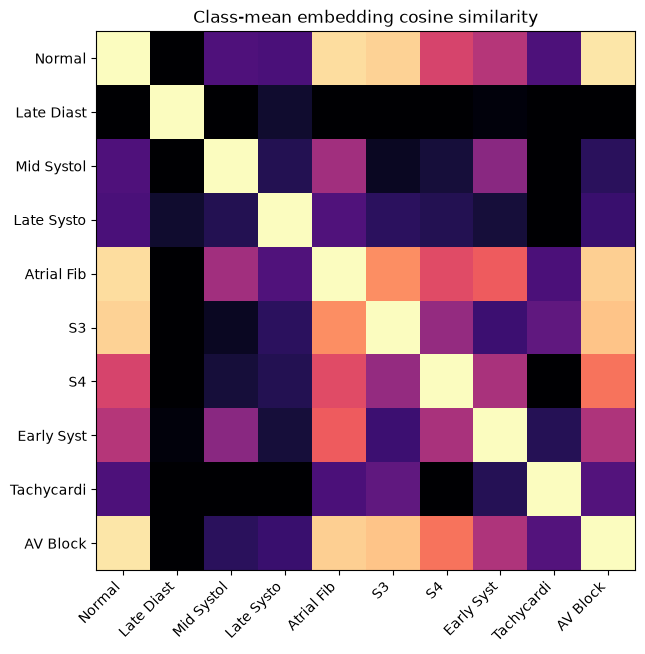

In [2]:

from cardia import features  # noqa
from cardia.features import embeddings as emb
MC = "/media/tnzr/AuxVolume/cardiasense-runs/mc"
try:
    data = emb.corpus_embeddings(DATA, MC)
    M = emb.class_mean_matrix(data)
    print("corpus", data["rows"]["sample_id"][:3], "...", len(data["rows"]["sample_id"]), "clips,", "classes", len(M))
    import matplotlib.pyplot as plt
    from cardia.config import HEART_TYPES
    fig, ax = plt.subplots(figsize=(8,7))
    ax.imshow(M, cmap="magma", vmin=0, vmax=1); ax.set_xticks(range(len(HEART_TYPES))); ax.set_yticks(range(len(HEART_TYPES)))
    ax.set_xticklabels([c[:10] for c in HEART_TYPES], rotation=45, ha="right")
    ax.set_yticklabels([c[:10] for c in HEART_TYPES])
    ax.set_title("Class-mean embedding cosine similarity"); plt.show()
except FileNotFoundError as e:
    print("checkpoints not available:", e)


### Generate one app-style report in-notebook

In [3]:

import sys
sys.path.insert(0, str(ROOT / "webapp"))
from webapp.app import inference, report
reg = inference.get_registry()     # warm-loads the head ensembles
opts = report.ReportOptions(heads=["source","heart_types"], figures="all", temporal=True,
                            temporal_mode="multiscale", explanation="standard")
span = __import__("soundfile", fromlist=["read"]).read if False else None
import soundfile as sf, torch
path = __import__("webapp.app.game", fromlist=["resolve_audio_path"]).resolve_audio_path("M0001", "sound", "binary")
wav, sr = sf.read(path, dtype="float32", always_2d=True)
rep = report.analyze_waveform(torch.from_numpy(wav[:,0]).squeeze(), int(sr), "M0001.wav", opts)
print("verdict:", rep["verdict"])
for k in ("timeline_source", "probs_heart_types"):
    print(k, "present:", k in rep["figures"])


verdict: no-flag
timeline_source present: True
probs_heart_types present: True


### Embedded audio + screenshots in the README

In [4]:

print("Audio assets:  docs/assets/audio/*.wav   (played inline in the GitHub README)")
print("Screenshots:   docs/walkthrough/*.png    (instructional walkthrough)")


Audio assets:  docs/assets/audio/*.wav   (played inline in the GitHub README)
Screenshots:   docs/walkthrough/*.png    (instructional walkthrough)
